<a href="https://colab.research.google.com/github/NAMU578/INFSUB/blob/main/notebooks/4_%ED%8C%90%EB%8B%A4%EC%8A%A4%EB%AA%A8%EB%93%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 판다스 모듈
파이썬에서 테이블 형태의 2차원 데이터를 쉽고 빠르게 다루기 위해 사용하는 데이터 분석 라이브러리

[판다스 공식 사이트](https://pandas.pydata.org/docs/getting_started/index.html#getting-started)


In [ ]:
import pandas as pd

## 시리즈(Series)와 데이터프레임(DataFrame) 개념
* Series:  이름표가 붙은 1차원 데이터
* DataFrame: Series를 묶은 2차원 표

### 시리즈(Series)

In [ ]:
# Series 만들기: 값 + 인덱스(이름표)
age = pd.Series([22, 38, 26, 35], index=['철수', '영희', '민수', '지연'], name='나이')
print(age)
print()

# Series의 3요소 확인
print("값(values):", age.values)     # 실제 데이터
print("인덱스(index):", age.index.tolist())  # 이름표를 리스트 형태로
print("이름(name):", age.name)


철수    22
영희    38
민수    26
지연    35
Name: 나이, dtype: int64

값(values): [22 38 26 35]
인덱스(index): ['철수', '영희', '민수', '지연']
이름(name): 나이


In [ ]:
# Series 다루기
# 인덱스로 값 꺼내기 (두 가지 방법)
print(age['영희'])        # 이름표로
print(age.iloc[1])        # 위치 번호로

# Series에 대한 통계 계산
print("평균:", age.mean(), "/ 최대:", age.max())

# Series에 대한 연산
print(age + 1)            # 내년 나이
print(age >= 30)          # 조건식의 결과 True / False

38
38
평균: 30.25 / 최대: 38
철수    23
영희    39
민수    27
지연    36
Name: 나이, dtype: int64
철수    False
영희     True
민수    False
지연     True
Name: 나이, dtype: bool


### 데이터프레임(DataFrame)

In [ ]:
# DataFrame 만들기: 딕셔너리를 데이터프레임으로 만들기
df_mini = pd.DataFrame({
    '나이':   [22, 38, 26, 35],
    '성별':   ['남', '여', '남', '여'],
    '탑승등급': [3, 1, 3, 1],
}, index=['철수', '영희', '민수', '지연'])
df_mini

,나이,성별,탑승등급
철수,22,남,3
영희,38,여,1
민수,26,남,3
지연,35,여,1


### 시리즈와 데이터프레임의 관계
DataFrame의 열 하나가 Series 라고 생각하면 됨<br>
df['열'] → Series(1차원)<br>
df[['열1','열2']] → DataFrame(2차원)<br>
이 구분이 이후 모든 문법의 기초

In [ ]:
col = df_mini['나이']     # 열 하나를 꺼내면
print(type(col))          # <class 'pandas.core.series.Series'> ← Series가 됨!

# 그래서 열에 바로 통계 함수를 사용할 수 있음.
print(df_mini['나이'].mean())

# 열을 여러 개 꺼내면 DataFrame (대괄호 2개 사용해야 함)
new_df_mini = df_mini[['나이', '성별']]
print(type(new_df_mini))   # DataFrame
print(new_df_mini)

<class 'pandas.core.series.Series'>
30.25
<class 'pandas.core.frame.DataFrame'>
    나이 성별
철수  22  남
영희  38  여
민수  26  남
지연  35  여


## 판다스를 이용하여 데이터 파일 읽기
실습을 위해 seaborn에 있는 타이타닉 데이터 저장<br>
csv 파일과 엑셀 파일 두 가지 형태로 저장


In [ ]:
import seaborn as sns

# 타이타닉 데이터를 받아 CSV와 엑셀, 두 가지 형태로 저장
titanic = sns.load_dataset('titanic')
titanic.to_csv('titanic.csv', index=False)                       # CSV로 저장
titanic.to_excel('titanic.xlsx', index=False, sheet_name='passengers')  # 엑셀로 저장

# 코랩 왼쪽 [파일] 아이콘을 눌러 두 파일이 생겼는지 눈으로 확인!
!ls -lh titanic.*


-rw-r--r-- 1 root root 56K Sep 15 13:06 titanic.csv
-rw-r--r-- 1 root root 55K Sep 15 13:06 titanic.xlsx


### csv 파일 읽기

In [ ]:
df = pd.read_csv('titanic.csv')
print(df.shape)     # (891, 15) : 891명, 15개 열
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### csv 파일 읽을 때 유용한 옵션들

In [15]:
# 필요한 열만, 필요한 행 수만 읽기 (대용량 데이터에서 필수 기술)
df_part = pd.read_csv('titanic.csv', usecols=['survived', 'sex', 'age'], nrows=10)
print(df_part)

# 그 밖에 자주 쓰는 옵션 (설명만 참고)
# pd.read_csv('파일.csv', encoding='cp949')   # 한글 깨질 때 (공공데이터 단골!)
# pd.read_csv('파일.csv', sep='\t')           # 콤마 대신 탭으로 구분된 파일일 때
# pd.read_csv('파일.csv', header=None)        # 제목 줄이 없는 파일

   survived     sex   age
0         0    male  22.0
1         1  female  38.0
2         1  female  26.0
3         1  female  35.0
4         0    male  35.0
5         0    male   NaN
6         0    male  54.0
7         0    male   2.0
8         1  female  27.0
9         1  female  14.0


### 엑셀 파일 읽기

In [13]:
df_xls = pd.read_excel('titanic.xlsx', sheet_name='passengers')
df_xls.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 두 방법 비교
내용이 같은지 확인해 보자<br>
[질문] 내용이 같다면 CSV와 엑셀 중 무엇으로 데이터를 배포하는 게 좋을까? <br>
[답변] CSV는 가볍고 어떤 프로그램에서나 열리며(범용성), 엑셀은 서식·여러 시트를 담을 수 있지만 무겁다. 실제 AI 연구용 공개 데이터셋 대부분이 CSV인 이유.


In [16]:
print("CSV :", df.shape)
print("엑셀:", df_xls.shape)
print("내용이 완전히 같은가?", df.equals(df_xls))   # True

# 이번 수업에서는 열 9개만 사용
df = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked','deck']]
df.head(3)


CSV : (891, 15)
엑셀: (891, 15)
내용이 완전히 같은가? True


,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN


## 판다스 기본 함수


In [17]:
# 데이터 훓어보기
print(df.shape)        # (행 수, 열 수)
print(df.columns.tolist())  # 열(속성, 시리즈) 이름 목록
df.head()              # 앞 5행 (df.head(10)처럼 개수 지정 가능)
# df.tail()            # 뒤 5행
# df.sample(5)         # 무작위 5행 — 데이터가 정렬돼 있을 때 유용


(891, 9)
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'deck']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,C
4,0,3,male,35.0,0,0,8.0500,S,NaN


In [18]:
# 데이터프레임의 정보 요약
df.info()

# info() 함수가 보여주는 데이터 읽는 법
#  ① Non-Null Count: 현재 데이터셋의 경우 891보다 작으면 결측치가 있다는 뜻 (age 714, deck 203!)
#  ② Dtype: int64/float64는 숫자, object는 문자
#  ③ memory usage: 데이터 크기

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   deck      203 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [21]:
# 수치형 통계 요약
df.describe()
# count(개수), mean(평균), std(표준편차), min, 25%/50%/75%(사분위수), max

# 문자형(범주형) 열의 요약은 따로
# df.describe(include='object')
# unique(종류 수), top(최빈값), freq(최빈값 빈도)


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
# 열 단위 통계 함수 활용해 보기
# 대표 함수: mean(), median(), max(), std(), corr()
print("평균 나이:", df['age'].mean())
print("중앙값:", df['age'].median())
print("최대 운임:", df['fare'].max())
print("표준편차:", df['age'].std())
print("나이-운임 상관계수:", df['age'].corr(df['fare']))

평균 나이: 29.69911764705882
중앙값: 28.0
최대 운임: 512.3292
표준편차: 14.526497332334044
나이-운임 상관계수: 0.0960666917690389


In [24]:
# 범주형 데이터 세기
print(df['pclass'].value_counts())                  # 등급별 인원
print()                                             # 단순 줄 바꿈
print(df['sex'].value_counts(normalize=True))       # 비율로 보기
print()                                             # 단순 줄 바꿈
print(df['embarked'].unique())                      # 값의 종류
print()                                             # 단순 줄 바꿈
print(df['embarked'].nunique())                     # 종류의 개수(결측값은 포함되지 않음)

pclass
3    491
1    216
2    184
Name: count, dtype: int64

sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

['S' 'C' 'Q' nan]

3


In [25]:
# 기준에 따른 정렬
# 운임이 비싼 순서로 5명
df.sort_values('fare', ascending=False).head() # 오름차순 False => 내림차순

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
679,1,1,male,36.0,0,1,512.3292,C,B
258,1,1,female,35.0,0,0,512.3292,C,NaN
737,1,1,male,35.0,0,0,512.3292,C,B
88,1,1,female,23.0,3,2,263.0000,S,C
438,0,1,male,64.0,1,4,263.0000,S,C


In [28]:
# 2개 기준 정렬: 등급 오름차순으로 정리하되 같은 등급에서는 나이가 내림차순으로
df.sort_values(['pclass', 'age'], ascending=[True, False]).head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
630,1,1,male,80.0,0,0,30.0000,S,A
96,0,1,male,71.0,0,0,34.6542,C,A
493,0,1,male,71.0,0,0,49.5042,C,NaN
745,0,1,male,70.0,1,1,71.0000,S,B
54,0,1,male,65.0,0,1,61.9792,C,B


## 결측치 확인 및 결측치 처리 방법

### 결측치 확인 방법

In [30]:
# 방법1: 가장 기본 — 열별 결측치 개수
print(df.isnull().sum())

# ※ isna()는 isnull()과 100% 동일한 함수 (둘 다 알아두기)
print("\nisna()와 isnull()은 같은가? ", df.isna().sum().equals(df.isnull().sum()))   # True

# 방법2: 결측 '비율'로 보기 — 처리 전략을 정할 때 더 유용!
print()
print((df.isnull().mean() * 100).round(1)) # 소수점 이하 한자리까지
# age 19.9%, deck 77.2% → 비율이 다르면 전략도 달라야 한다

# 방법3: info()의 Non-Null Count로 확인 (전체 행 수와 비교)
print()
print(df.info())

# 방법4: 반대로 세기 — 값이 '있는' 것 개수
print()
print(df['age'].count())            # NaN을 제외하고 센다
print(df['age'].notnull().sum())    # 같은 결과


survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
deck        688
dtype: int64

isna()와 isnull()은 같은가?  True

survived     0.0
pclass       0.0
sex          0.0
age         19.9
sibsp        0.0
parch        0.0
fare         0.0
embarked     0.2
deck        77.2
dtype: float64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   deck      203 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB
None

714
714


In [36]:
# 결측이 하나라도 있는 '행'은 몇 개?
print(df.isnull().any(axis=1).sum(), "행")
# 왜 행인데 axis1(열방향) 으로 진행하는가에 대한 답:열 방향으로, 각 열마다의 모든 행에 대해서 결측 여부를 계산하는것임. 1열에서 3,5행 2개, 2열에서 4,7,8행 3개 ~~~

# 데이터 전체의 결측 총 개수
print() #간격띄우기용
print(df.isnull().sum().sum(), "개") # isnull():모든 원소에 대해 true,false여부를 보여줌. sum()을 한번 더하면, 열별 결측 개수를 보여주고, sum()을 또 하면 총합.

# 나이가 비어 있는 승객을 직접 눈으로 확인
df[df['age'].isnull()]            # 이런 불리언 인덱싱 엄청 많이 사용함
# df[df['age'].isnull()].head()   # 그중에 위쪽 5개만 보자

709 행

867 개


,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
5,0,3,male,NaN,0,0,8.4583,Q,NaN
17,1,2,male,NaN,0,0,13.0000,S,NaN
19,1,3,female,NaN,0,0,7.2250,C,NaN
26,0,3,male,NaN,0,0,7.2250,C,NaN
28,1,3,female,NaN,0,0,7.8792,Q,NaN
...,...,...,...,...,...,...,...,...,...
859,0,3,male,NaN,0,0,7.2292,C,NaN
863,0,3,female,NaN,8,2,69.5500,S,NaN
868,0,3,male,NaN,0,0,9.5000,S,NaN
878,0,3,male,NaN,0,0,7.8958,S,NaN


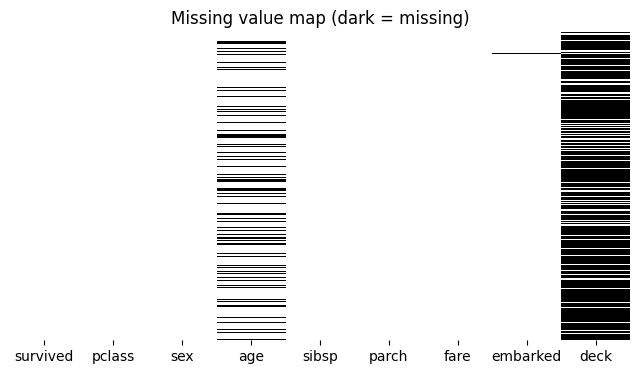

In [37]:
# 결측 위치를 그림으로 보기
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='gray_r')
plt.title('Missing value map (dark = missing)')
plt.show()
# deck 열이 거의 까맣게(결측) 나오는 것을 확인!


# 결측치 시각화 코드 설명

- `df.isnull()`: 각 셀이 NaN인지 True/False로 변환
- `sns.heatmap()`: True/False를 색상으로 변환해 2D 그리드에 표시
- `cbar=False`: 컬러바(범례) 제거
- `yticklabels=False`: Y축 행 레이블 숨김 (많은 행일 때 깔끔함)
- `cmap='gray_r'`: gray를 뒤집은 컬러맵. 원래는 정상데이터가 검정, 결측치가 흰색이나 정상 데이터는 흰색, 결측치는 검은색으로 표현


### 결측치 처리 방법

In [38]:
# 전체 평균으로 채우기
df1 = df.copy()   # 원본 보존! (처리 방법을 비교하기 위해 복사본 사용)

print("채우기 전 결측:", df1['age'].isnull().sum())
df1['age'] = df1['age'].fillna(df1['age'].mean())   # 평균 약 29.7세로 일괄 대체
print("채운 후 결측:", df1['age'].isnull().sum())

# pandas 2.x 주의: df1['age'].fillna(값, inplace=True)는 경고 발생함.
# 즉, 이전 버전에서 사용하던 inplace=True 옵션 사용은 하지 말것.

채우기 전 결측: 177
채운 후 결측: 0


In [40]:
# 그룹의 평균으로 채우기
# 예제)남녀 그룹별 평균으로 채우기
df2 = df.copy()
print(df2[df2['age'].isnull()].head())

# 근거 확인: 그룹마다 평균 나이가 정말 다른가?
print()
print(df2.groupby(['pclass', 'sex'])['age'].mean().round(1)) #클래스,성별로 묶인 그룹중에서 나이만 선별하여 평균. 소수점 1자리까지만 표시

# '같은 등급, 같은 성별' 그룹의 평균으로 채우기
df2['age'] = df2.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.mean()))

print()
print("처리 후 결측:", df2['age'].isnull().sum())

# 나이 결측치가 있었던 5번 자료에 대해 처리 결과를 확인해 보자
print()
# print(df2.iloc[[5]])
display(df2.iloc[[5]])

    survived  pclass     sex  age  sibsp  parch     fare embarked deck
5          0       3    male  NaN      0      0   8.4583        Q  NaN
17         1       2    male  NaN      0      0  13.0000        S  NaN
19         1       3  female  NaN      0      0   7.2250        C  NaN
26         0       3    male  NaN      0      0   7.2250        C  NaN
28         1       3  female  NaN      0      0   7.8792        Q  NaN

pclass  sex   
1       female    34.6
        male      41.3
2       female    28.7
        male      30.7
3       female    21.8
        male      26.5
Name: age, dtype: float64

처리 후 결측: 0



,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
5,0,3,male,26.507589,0,0,8.4583,Q,NaN


In [41]:
# 결측치가 있는 데이터 삭제
df3 = df.copy()
print("원본 행 수:", len(df3))

# 1) 결측이 하나라도 있는 행 전부 삭제 — 가장 단순하지만 가장 위험
print()
print("dropna():", len(df3.dropna()), "행")   # 891 → 182행! (deck 때문에 대참사)

# 2) 특정 열 기준으로만 삭제 — 실무에서 가장 많이 쓰는 형태
# 여기서는 나이에 결측치가 있는 데이터 삭제해 보면
print()
print("dropna(subset=['age']):", len(df3.dropna(subset=['age'])), "행")   # 714행

# 3) '열'을 삭제 — 결측이 너무 많은 열은 채우기보다 버리는 게 낫다
print()
print("deck 결측 비율: 77%  → 열 삭제가 합리적")
df3 = df3.drop(columns=['deck'])
print("drop 후 열:", df3.columns.tolist())

원본 행 수: 891

dropna(): 182 행

dropna(subset=['age']): 714 행

deck 결측 비율: 77%  → 열 삭제가 합리적
drop 후 열: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


In [42]:
# 범주형의 경우 최빈값으로 채익
df4 = df.copy()

# embarked(탑승 항구)는 문자라서 '평균'이 없다 → 최빈값(mode)으로 채움
# mode()는 최빈값이 여러 개일 수 있기 때문에 Series 형태로 결과 반환
# 그중 가장 최빈값을 알려면 mode()[0]을 붙여서 표현
print("최빈값:", df4['embarked'].mode()[0])
df4['embarked'] = df4['embarked'].fillna(df4['embarked'].mode()[0])
print("처리 후 결측:", df4['embarked'].isnull().sum())

최빈값: S
처리 후 결측: 0
